Dharmraj sodha 
47 - Div B 
24SOECE13043

Tutorial 3: Implement KNN and SVM

Let us implement the algorithm with the help of the 'Mobile.csv' dataset.
It contains data about customers “Age”, “EstimatedSalary”, “Purchased” .
Download the dataset from the shared folder.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
m = pd.read_csv('mobile.csv')
m.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [3]:
m.isna().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [4]:
purcahseddata = m[['Age','EstimatedSalary','Purchased']][m["Purchased"]==1]
purcahseddata

,Age,EstimatedSalary,Purchased
7,32,150000,1
16,47,25000,1
17,45,26000,1
18,46,28000,1
19,48,29000,1
...,...,...,...
393,60,42000,1
395,46,41000,1
396,51,23000,1
397,50,20000,1


In [5]:
not_purcahseddata = m[['Age','EstimatedSalary','Purchased']][m["Purchased"]==0]
not_purcahseddata

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
377,42,53000,0
380,42,64000,0
387,39,71000,0
394,39,59000,0


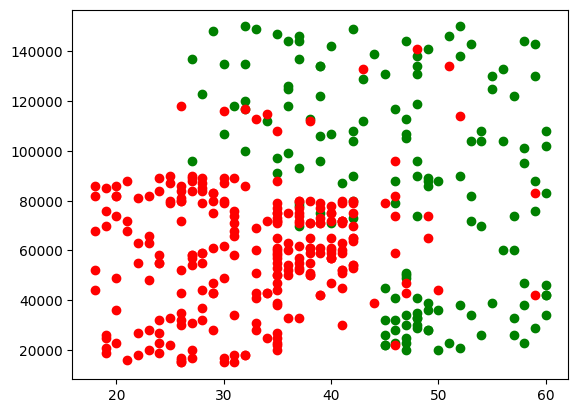

In [6]:
plt.scatter(purcahseddata["Age"],purcahseddata["EstimatedSalary"],c = "green")
plt.scatter(not_purcahseddata["Age"],not_purcahseddata["EstimatedSalary"],c = "red")

In [7]:
m["EstimatedSalary"].max()

np.int64(150000)

In [8]:
m["EstimatedSalary"].min()

np.int64(15000)

In [9]:
m["Age"].max()

np.int64(60)

In [10]:
m["Age"].min()

np.int64(18)

In [11]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
features_to_scale = ["Age","EstimatedSalary"]
scaled_values = scaler.fit_transform(m[features_to_scale])
m["norm_Age"] = scaled_values[:,0]
m["norm_Salary"] = scaled_values[:,1]
m.head()

,Age,EstimatedSalary,Purchased,norm_Age,norm_Salary
0,19,19000,0,0.023810,0.029630
1,35,20000,0,0.404762,0.037037
2,26,43000,0,0.190476,0.207407
3,27,57000,0,0.214286,0.311111
4,19,76000,0,0.023810,0.451852


In [12]:
from sklearn.model_selection import train_test_split
#selecting the predicators and target
X=m[['norm_Age','norm_Salary']]
y=m['Purchased']
#splitting data into train and test data set
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=100)

In [13]:
X_train,X_test,y_train,y_test

(     norm_Age  norm_Salary
 190  0.142857     0.511111
 46   0.166667     0.474074
 50   0.142857     0.125926
 377  0.571429     0.281481
 121  0.452381     0.422222
 ..        ...          ...
 343  0.690476     0.266667
 359  0.571429     0.288889
 323  0.714286     0.111111
 280  0.976190     0.540741
 8    0.166667     0.133333
 
 [320 rows x 2 columns],
      norm_Age  norm_Salary
 248  0.547619     0.274074
 318  0.642857     0.125926
 173  0.380952     0.207407
 285  0.452381     0.577778
 184  0.357143     0.333333
 ..        ...          ...
 358  0.523810     0.414815
 166  0.095238     0.296296
 198  0.190476     0.481481
 267  0.452381     0.437037
 69   0.309524     0.392593
 
 [80 rows x 2 columns],
 190    0
 46     0
 50     0
 377    0
 121    0
       ..
 343    1
 359    0
 323    1
 280    1
 8      0
 Name: Purchased, Length: 320, dtype: int64,
 248    0
 318    1
 173    0
 285    1
 184    0
       ..
 358    1
 166    0
 198    0
 267    0
 69     0
 Name: Pur

In [14]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=3,metric="euclidean")
model.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [15]:
model.score(X_train,y_train) * 100

94.0625

In [16]:
model.score(X_test,y_test) * 100

88.75

Exercise 2: SVM for classification.

Consider the Iris dataset which provides measurements of sepal length, sepal width, petal length, and petal width for 50 flowers from each of 3 species. Total rows are 150.

In [17]:
i = pd.read_csv("iris.csv")
i.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [18]:
i.isna().sum()

Sepal.Length    0
Sepal.Width     0
Petal.Length    0
Petal.Width     0
Species         0
dtype: int64

In [19]:
v_nu_fn = lambda x: 0 if x=="versicolor" else 1
i["v_nv"] = i["Species"].apply(v_nu_fn)
i

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,v_nv
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,1
146,6.3,2.5,5.0,1.9,virginica,1
147,6.5,3.0,5.2,2.0,virginica,1
148,6.2,3.4,5.4,2.3,virginica,1


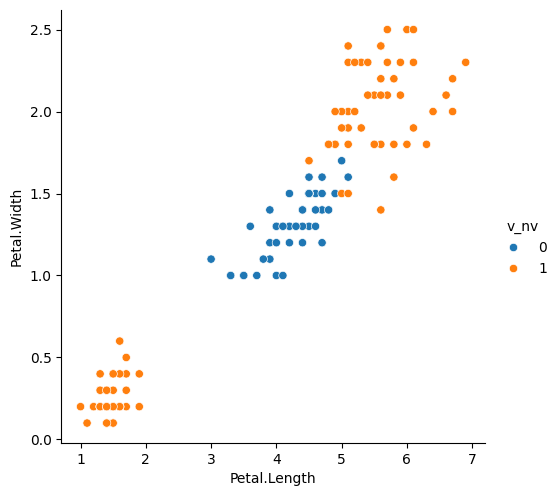

In [20]:
import seaborn as sns
sns.pairplot(i, x_vars="Petal.Length",y_vars="Petal.Width",hue="v_nv", height=5)

In [21]:
from sklearn.svm import SVC
X =i[["Petal.Length","Petal.Width"]]
y =i["v_nv"]
model = SVC()
model.fit(X,y)
model.score(X, y)*100

95.33333333333334

In [22]:
pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
  Using cached mlxtend-0.24.0-py3-none-any.whl.metadata (7.3 kB)
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   --------------------------

C:\Users\dharm\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Decision boundary of SVM on iris data')

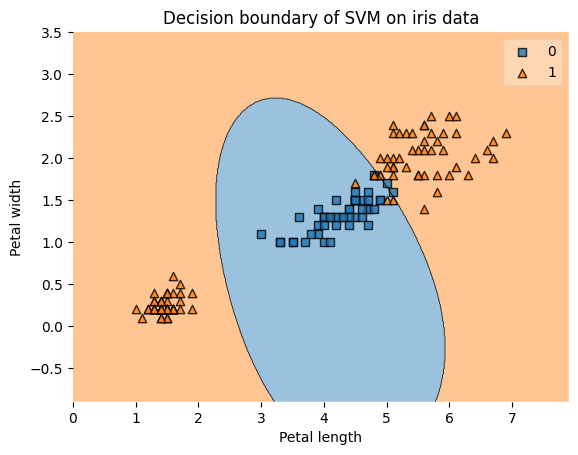

In [23]:
from mlxtend.plotting import plot_decision_regions
features = np.array(X)
taget = np.array(y)
plot_decision_regions(features, taget, clf=model)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title('Decision boundary of SVM on iris data')

In [24]:
i

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,v_nv
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,1
146,6.3,2.5,5.0,1.9,virginica,1
147,6.5,3.0,5.2,2.0,virginica,1
148,6.2,3.4,5.4,2.3,virginica,1


In [25]:
from sklearn.preprocessing import LabelEncoder
label= LabelEncoder()
i["Species"] = label.fit_transform(i["Species"])
i

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,v_nv
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,1
146,6.3,2.5,5.0,1.9,2,1
147,6.5,3.0,5.2,2.0,2,1
148,6.2,3.4,5.4,2.3,2,1


In [26]:
X =i[["Petal.Length","Petal.Width"]]
Y =i["Species"]
model = SVC()
model.fit(X,Y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


C:\Users\dharm\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'multiclass classification on iris using SVM')

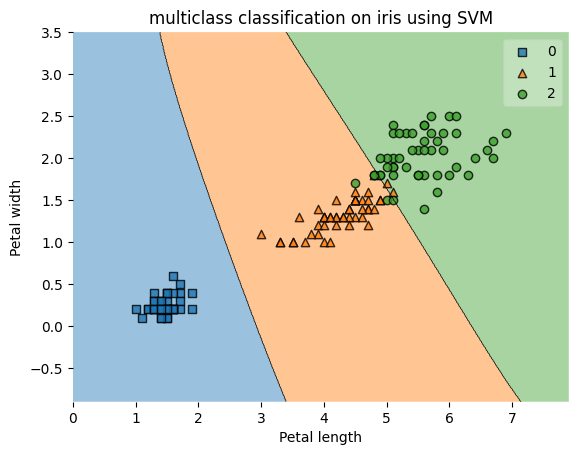

In [27]:
from mlxtend.plotting import plot_decision_regions
features = np.array(X)
taget = np.array(Y)
plot_decision_regions(features, taget, clf=model)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title('multiclass classification on iris using SVM')